<a href="https://colab.research.google.com/github/SindhaAshish/Super-Store-Sales/blob/main/Superstore_Sales_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Super Store Sales Prediction

##1. Data Loading & Preparation

In [1]:
#let's import important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import google.colab as colab
from google.colab import drive
#drive.mount('/content/drive')
import google.colab.files as files
from google.colab import files
uploaded = files.upload()

Saving superstoresales_train.csv to superstoresales_train.csv


In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
df = pd.read_csv('superstoresales_train.csv')

In [4]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [5]:
#df['Sales'] = df['Sales'].astype('float32')
#df['estimated_profit'] = df['Sales'] * 0.15
df['estimated_profit'] = df['sales'].astype('float32') * 0.15
#df['estimated_profit'] = pd.eval("df['Sales'] * 0.15") not working
#df['estimated_profit'] = (df['Sales'] * 0.15)

In [6]:
df['order_date'] = df['order_date'].astype('datetime64[ns]')
df['ship_date'] = df['ship_date'].astype('datetime64[ns]')

In [7]:
df.isnull().head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,estimated_profit
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


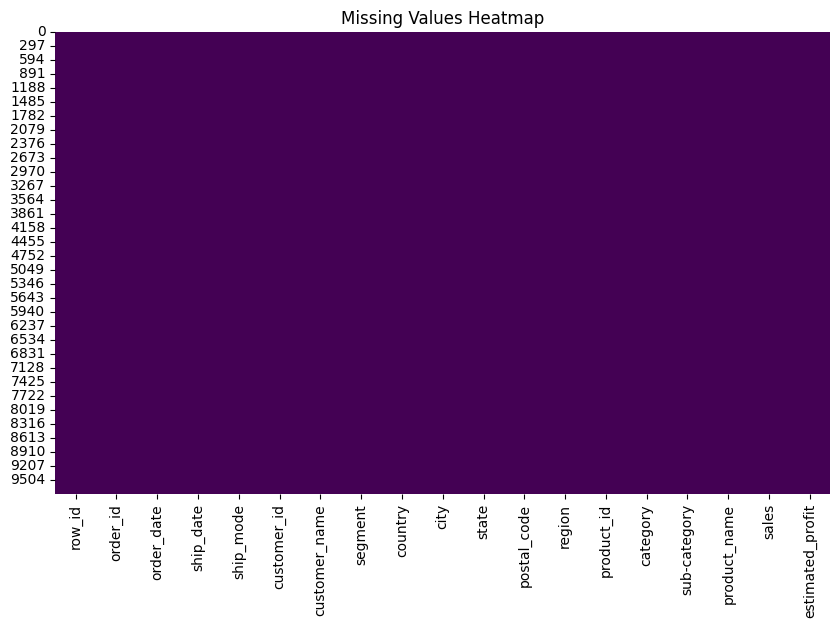

In [9]:
#Generating Heatmap with Missing Values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar = False,cmap = 'viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [10]:
#df=df.drop_duplicates().head()

In [11]:
#df=df.dropna().head()

In [12]:
df.describe()

,row_id,order_date,ship_date,postal_code,sales,estimated_profit
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769079,34.615364
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.440000,0.066000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.250000,2.587500
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,8.173500
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,31.590751
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,3395.772217
std,2829.160653,NaN,NaN,32041.223413,626.651906,93.997665


## 2. Exploratory Data Analysis

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
display(df[['order_date','ship_date']].head())

,order_date,ship_date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [14]:
df['fastest_shipping_days'] = df['ship_date'] - df['order_date']
df['fastest_shipping_days'] = df['fastest_shipping_days'].dt.days
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,estimated_profit,fastest_shipping_days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,39.293999,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,109.791008,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.193000,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,143.637009,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,3.355500,7


In [15]:
average_shipping_time = df['fastest_shipping_days'].mean()
print(f"Average shipping time: {average_shipping_time:.2f} days")

Average shipping time: 3.96 days


In [16]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,estimated_profit,fastest_shipping_days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,39.293999,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,109.791008,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.193000,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,143.637009,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,3.355500,7


In [17]:
#Fastest Shipping Days by Shipping Modes
average_shipping_time_by_mode = df.groupby('ship_mode')['fastest_shipping_days'].mean()
display(average_shipping_time_by_mode)

,fastest_shipping_days
ship_mode,
First Class,2.179214
Same Day,0.044610
Second Class,3.249211
Standard Class,5.008363


In [18]:
average_shipping_time_by_region = df.groupby('region')['fastest_shipping_days'].mean()
display(average_shipping_time_by_region)

,fastest_shipping_days
region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


In [19]:
average_sales = df['sales'].mean()
#display(average_sales)
print(f"Average Sales: {average_sales:.2f}")

Average Sales: 230.77


In [20]:
average_sales_by_region = df.groupby('region')['sales'].mean()
display(average_sales_by_region)

,sales
region,
Central,216.357883
East,240.401741
South,243.524061
West,226.184640


In [21]:
average_sales_by_category_sub_category = df.groupby(['category','sub-category'])['sales'].mean()
display(average_sales_by_category_sub_category)

category         sub-category
Furniture        Bookcases        503.598451
                 Chairs           531.833196
                 Furnishings       95.823824
                 Tables           645.894172
Office Supplies  Appliances       227.926754
                 Art               34.019643
                 Binders          134.067574
                 Envelopes         65.032339
                 Fasteners         14.027710
                 Labels            34.587423
                 Paper             57.420284
                 Storage          263.633858
                 Supplies         252.284185
Technology       Accessories      217.178175
                 Copiers         2215.879848
                 Machines        1645.553739
                 Phones           374.180925
Name: sales, dtype: float64

In [22]:
estimated_profit_by_region = df.groupby('region')['estimated_profit'].sum()
display(estimated_profit_by_region)

,estimated_profit
region,
Central,73897.039062
East,100427.828125
South,58372.718750
West,106532.968750


In [23]:
estimated_profit_by_category = df.groupby('category')['estimated_profit'].sum()
display(estimated_profit_by_category)

,estimated_profit
category,
Furniture,109298.820312
Office Supplies,105813.343750
Technology,124118.398438


In [24]:
estimated_profit_by_sub_category = df.groupby('sub-category')['estimated_profit'].sum()
display(estimated_profit_by_sub_category)

,estimated_profit
sub-category,
Accessories,24628.005859
Appliances,15692.757812
Art,4005.813232
Binders,30004.324219
Bookcases,17071.988281
Chairs,48423.414062
Copiers,21937.210938
Envelopes,2419.203125
Fasteners,450.289520


In [25]:
average_estimated_profit = df['estimated_profit'].mean()
display(average_estimated_profit)

np.float32(34.615364)

##3. Data Visualisation with Matplotlib and Seaborn

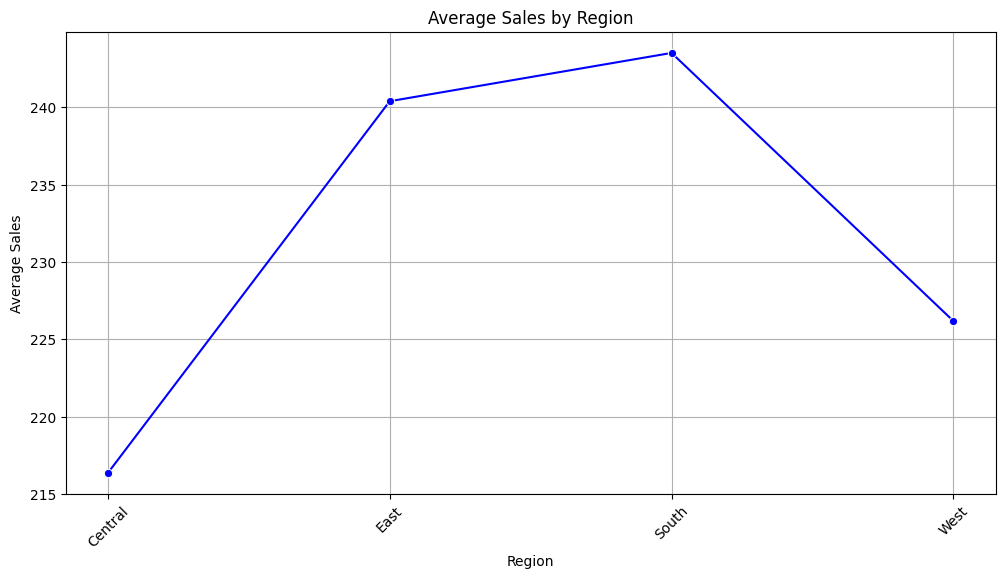

In [26]:
plt.figure(figsize=(12,6))
sns.lineplot(x=average_sales_by_region.index,y=average_sales_by_region.values,marker='o',color='blue')
plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

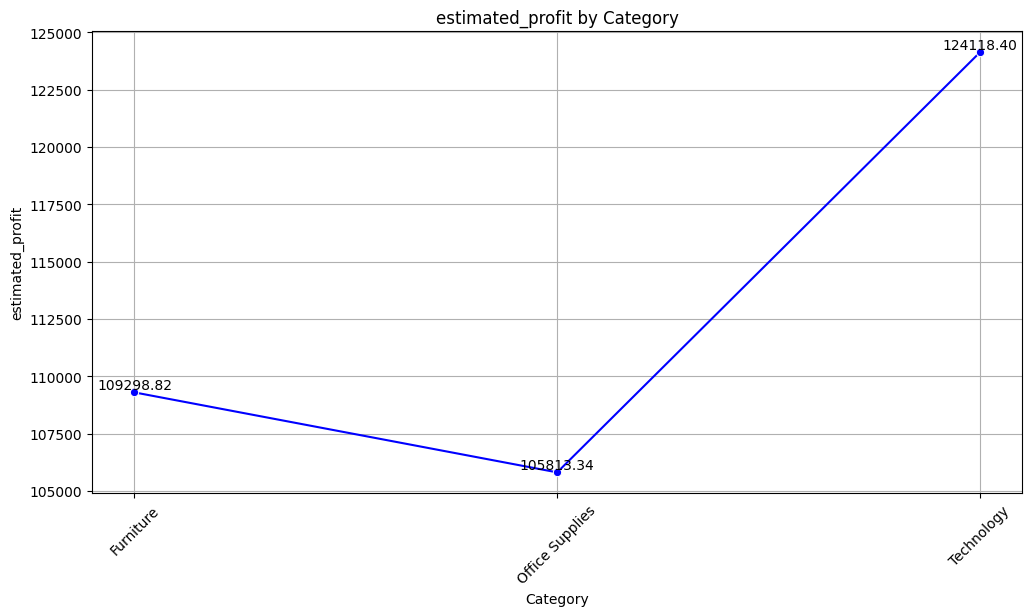

In [27]:
plt.figure(figsize=(12,6))
sns.lineplot(x=estimated_profit_by_category.index,y=estimated_profit_by_category.values,marker='o',color='blue')
plt.title('estimated_profit by Category')
plt.xlabel('Category')
plt.ylabel('estimated_profit')
plt.xticks(rotation=45)
plt.grid(True)
#Add Values Above Data point
for x,y in zip(estimated_profit_by_category.index,estimated_profit_by_category.values):
  plt.text(x,y,f'{y:.2f}',ha='center',va='bottom')

plt.show()

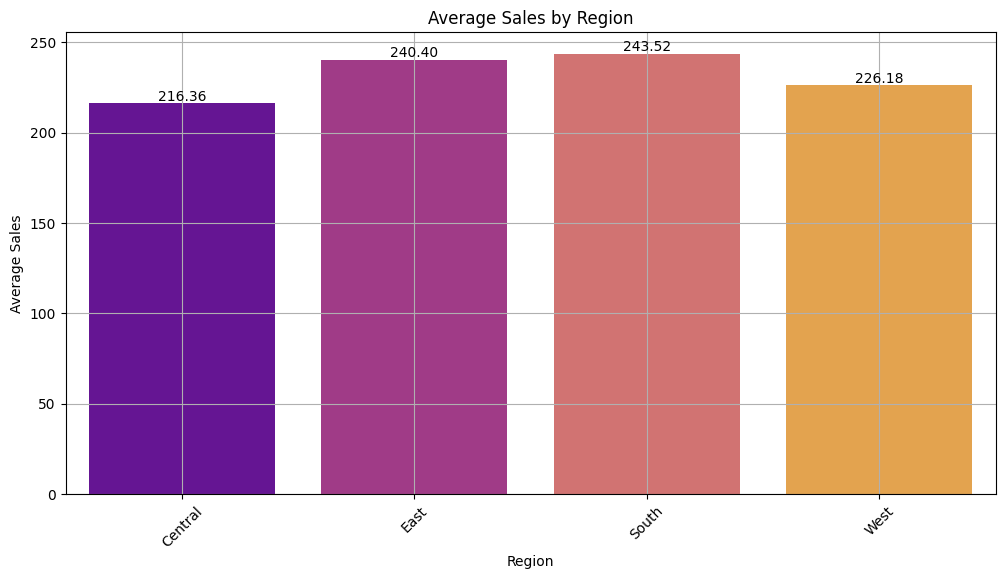

In [28]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x=average_sales_by_region.index,y=average_sales_by_region.values,palette='plasma', hue=average_sales_by_region.index, legend=False)
plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid()

# Add values above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='top', xytext=(0, 10), textcoords='offset points')

plt.show()

/tmp/ipykernel_3835/2900880222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=average_shipping_time_by_mode.index,y=average_shipping_time_by_mode.values,palette='viridis')


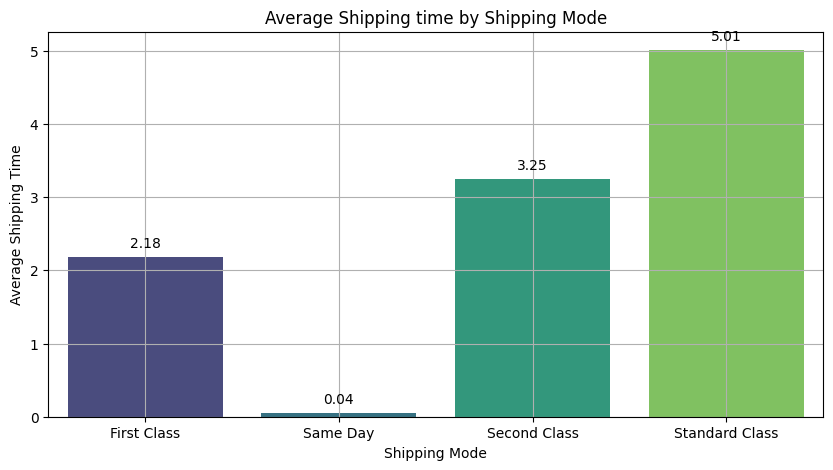

In [29]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x=average_shipping_time_by_mode.index,y=average_shipping_time_by_mode.values,palette='viridis')
plt.title('Average Shipping time by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Time')
plt.grid()

# Add values above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

### estimated_profit by Sub-Category
This bar chart will show the total estimated_profit generated by each sub-category, allowing for a detailed comparison of estimated_profitability across product types.

/tmp/ipykernel_3835/1235552639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=estimated_profit_by_sub_category.index,y=estimated_profit_by_sub_category.values,palette='viridis')


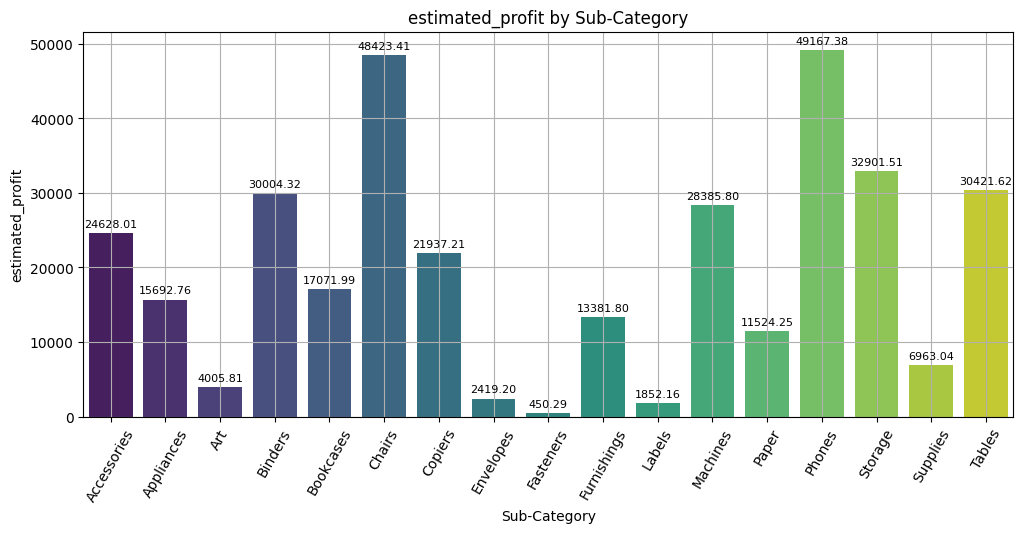

In [30]:
plt.figure(figsize=(12,5))
ax = sns.barplot(x=estimated_profit_by_sub_category.index,y=estimated_profit_by_sub_category.values,palette='viridis')
plt.title('estimated_profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('estimated_profit')
plt.grid()
plt.xticks(rotation=60)

#Add Data Points on Bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',(p.get_x()+p.get_width()/2.,p.get_height()),
    ha='center',va='top',xytext=(0,10),textcoords='offset points',fontsize=8)

#plt.tight_layout()
plt.show()

### Distribution of Sales
A histogram will help understand the frequency distribution of `sales` values, showing if sales are concentrated in certain ranges or are widely spread.

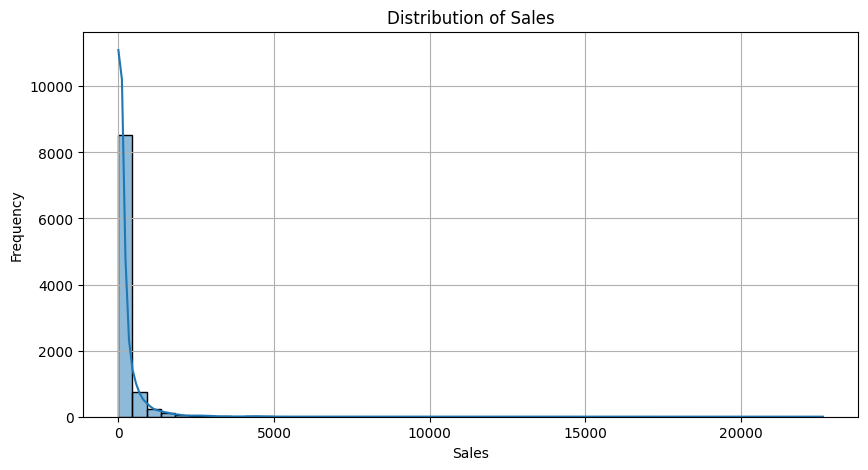

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(df['sales'],bins=50,kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Monthly Sales Trend
By extracting the month and year from the `order_date`, we can analyze how sales have changed over time, revealing seasonality or growth trends.

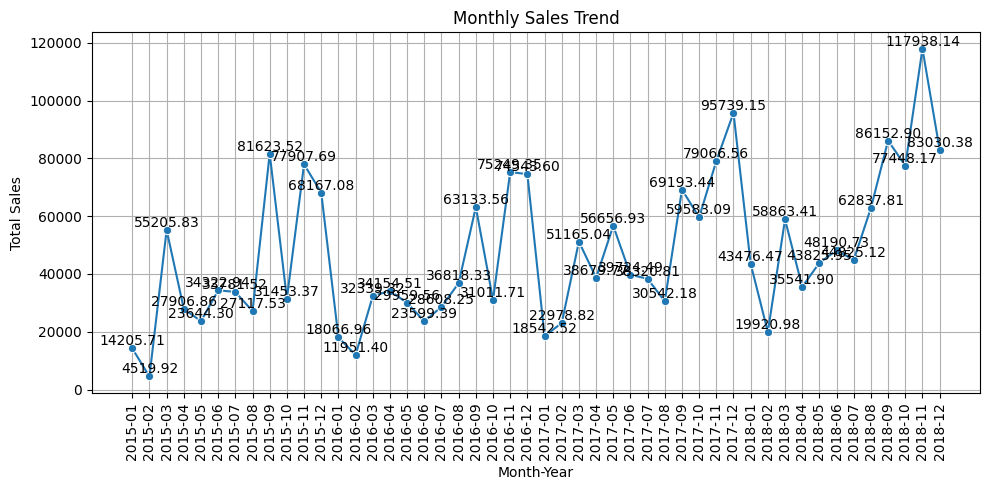

In [32]:
df['order_year_month']=df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_year_month')['sales'].sum().reset_index()
monthly_sales['order_year_month']=monthly_sales['order_year_month'].astype(str)

plt.figure(figsize=(10,5))
sns.lineplot(x='order_year_month',y='sales',data=monthly_sales,marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.grid(True)

for x,y in zip(monthly_sales['order_year_month'],monthly_sales['sales']):
  plt.text(x,y,f'{y:.2f}',ha='center',va='bottom')

plt.tight_layout()
plt.show()

### Total Sales by Customer Segment
This bar chart illustrates the total sales attributed to each customer segment, providing insights into which segments contribute most to the overall revenue.

/tmp/ipykernel_3835/375505432.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='segment',y='sales',data=total_sales_by_segment,palette='viridis')


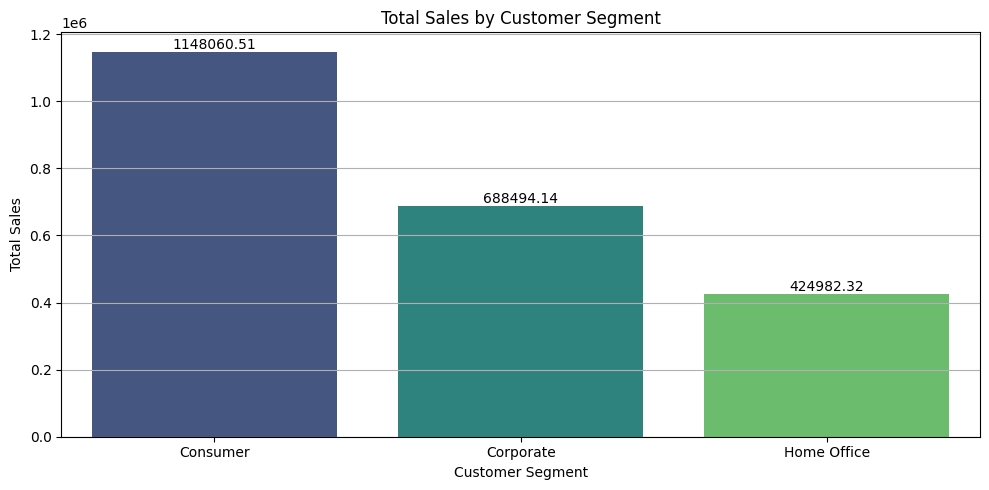

In [33]:
total_sales_by_segment = df.groupby('segment')['sales'].sum().reset_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(x='segment',y='sales',data=total_sales_by_segment,palette='viridis')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.grid(axis='y')

# Add values above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Top 10 Products by Total Sales
This bar chart highlights the top 10 products that have generated the highest total sales, offering insights into best-selling items.

/tmp/ipykernel_3835/3410659340.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='sales',y='product_name',data=top_10_products,palette='viridis')


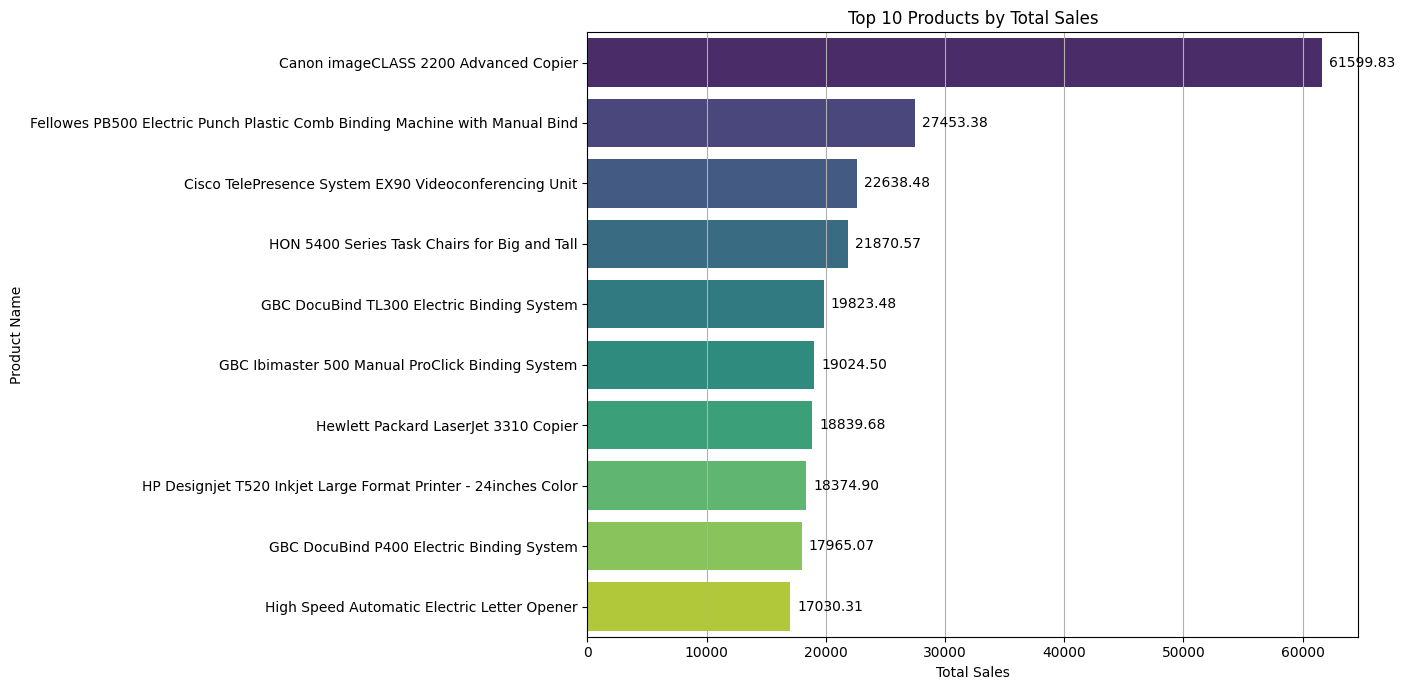

In [34]:
top_10_products = df.groupby('product_name')['sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14,7))
ax = sns.barplot(x='sales',y='product_name',data=top_10_products,palette='viridis')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.grid(axis='x')

#Adding data labels
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(),p.get_y() + p.get_height()/2.),
                ha = 'left', va = 'center',xytext=(5,0),textcoords='offset points')
plt.tight_layout()
plt.show()

### Top 5 Customers by Total Sales
This chart identifies the five customers who have generated the highest total sales, indicating key revenue drivers.

/tmp/ipykernel_3835/3593381401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='sales',y='customer_name',data=top_5_customers,palette='plasma')


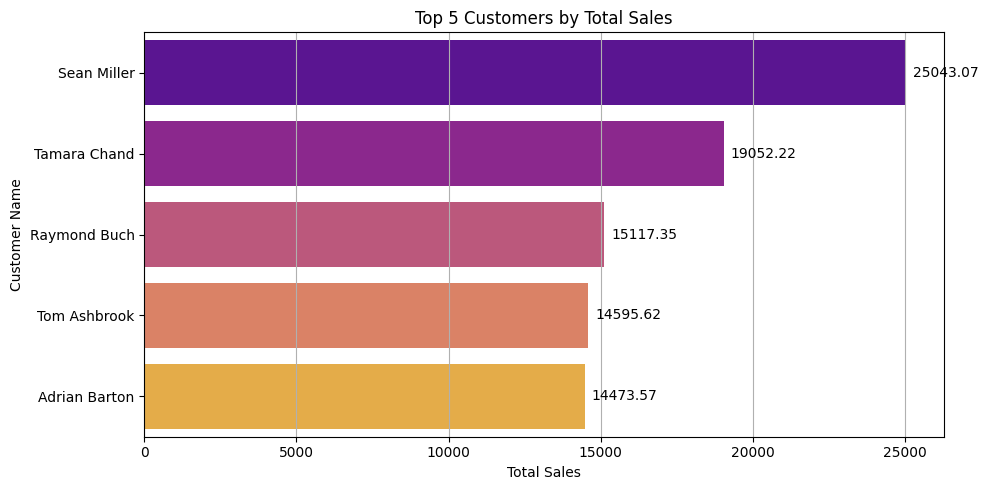

In [35]:
top_5_customers = df.groupby('customer_name')['sales'].sum().nlargest(5).reset_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(x='sales',y='customer_name',data=top_5_customers,palette='plasma')
plt.title('Top 5 Customers by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.grid(axis='x')

#Add Data labels
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}',(p.get_width(),p.get_y() + p.get_height()/2.),
                ha = 'left', va = 'center',xytext=(5,0),textcoords='offset points')
plt.tight_layout()
plt.show()

### Correlation between Discounts and Sales
Calculating the Pearson correlation coefficient between 'discount' and 'sales' will help us understand if there is a linear relationship between the two, i.e., whether increasing discounts tend to lead to higher or lower sales.

In [36]:
if 'discount' in df.columns and 'sales' in df.columns:
  correlation = df['discount'].corr(df['sales'])
  print(f"Pearson Correlation Coefficient: {correlation:.2f}")
else:
  print("One or both of 'discount' and 'sales' columns are missing in the DataFrame")

One or both of 'discount' and 'sales' columns are missing in the DataFrame


##4. Statastics Foundations

##4.1 Correlation Heatmap

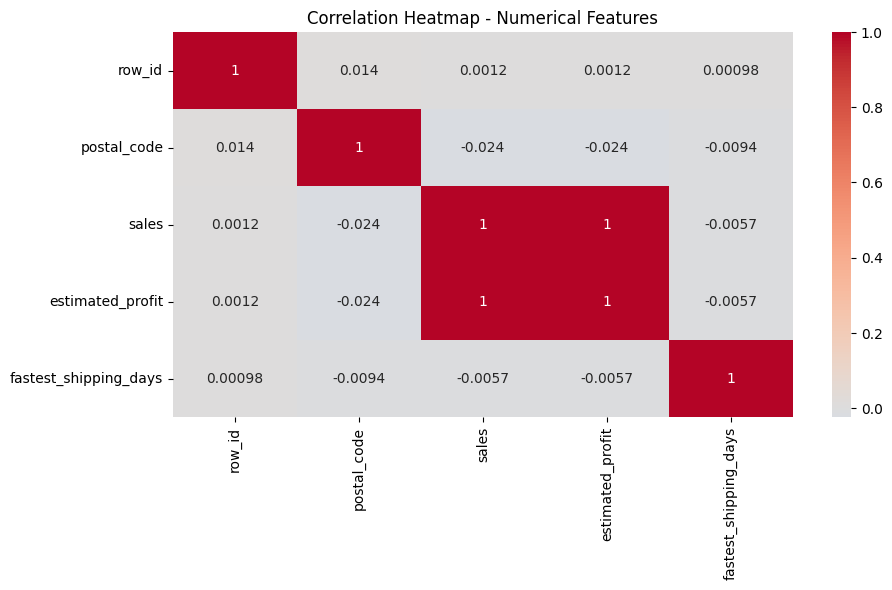

In [37]:
numerical_columns = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,5))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', center = 0)
plt.title('Correlation Heatmap - Numerical Features')
plt.show()

##4.2 Anova - Do categorical features significantly affect Price?

In [38]:
cat_columns_for_anova = df.select_dtypes(exclude=np.number).columns

# Columns to apply string cleaning (str.strip().str.title())
# Exclude datetime and period columns from string cleaning
cols_to_clean_as_string = [col for col in cat_columns_for_anova if col not in ['order_date', 'ship_date', 'order_year_month']]

for col in cols_to_clean_as_string:
  if col in df.columns:
    df[col] = df[col].astype(str).str.strip().str.title()

print(f'---{list(cat_columns_for_anova)} (Unique Values After Cleaning)---')

# Print unique values for all non-numeric columns for context, including temporal ones.
for col in cat_columns_for_anova:
  print(f'{col}:{df[col].nunique()} Unique Values')

---['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'order_year_month'] (Unique Values After Cleaning)---
order_id:4922 Unique Values
order_date:1230 Unique Values
ship_date:1326 Unique Values
ship_mode:4 Unique Values
customer_id:793 Unique Values
customer_name:793 Unique Values
segment:3 Unique Values
country:1 Unique Values
city:529 Unique Values
state:49 Unique Values
region:4 Unique Values
product_id:1861 Unique Values
category:3 Unique Values
sub-category:17 Unique Values
product_name:1849 Unique Values
order_year_month:48 Unique Values


In [39]:
from scipy import stats

cat_columns = ['state','product_id','product_name','category','sub-category']

for col in cat_columns:
  # Only perform ANOVA if there are at least two unique values in the column
  if df[col].nunique() > 1:
    groups = [g['sales'].dropna().values for _,g in df.groupby(col)]
    #Ensure each group has at least one observation before passing to f_oneway
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
      f_stat, p_val = stats.f_oneway(*groups)
      print(f'{col:15s} F-stat = {f_stat:3.2f} P-value = {p_val:6f} Significant = {p_val<0.05}')
    else:
      print(f'{col:15s} Cannot perform Anova: Not enough groups or observation')
  else:
    print(f'{col:15s} Cannot perform Anova: Only one unique value.')

state           F-stat = 1.86 P-value = 0.000307 Significant = True
product_id      F-stat = 18.53 P-value = 0.000000 Significant = True
product_name    F-stat = 19.34 P-value = 0.000000 Significant = True
category        F-stat = 262.16 P-value = 0.000000 Significant = True
sub-category    F-stat = 152.33 P-value = 0.000000 Significant = True


In [40]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Exclude 'State' , 'product_id' and 'product_name' due to high cardinality
cat_columns = ['category','sub-category']

for col in cat_columns:
  clean = df.dropna(subset=[f'sales',col])

  # Perform Tukey's HSD Test
  tukey = pairwise_tukeyhsd(
      endog = clean['sales'],
      groups = clean[col],
      alpha = 0.05
  )

  print(f'---{col}---')
  print(tukey)

---category---
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1          group2      meandiff p-adj  lower     upper   reject
-------------------------------------------------------------------------
      Furniture Office Supplies -231.2729   0.0 -267.776 -194.7698   True
      Furniture      Technology  105.7476   0.0  59.7509  151.7443   True
Office Supplies      Technology  337.0205   0.0 298.5944  375.4467   True
-------------------------------------------------------------------------
---sub-category---
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
   group1      group2    meandiff  p-adj    lower      upper    reject
----------------------------------------------------------------------
Accessories  Appliances    10.7486    1.0  -104.1175   125.6146  False
Accessories         Art  -183.1585    0.0  -282.0768   -84.2403   True
Accessories     Binders   -83.1106 0.0775  -169.7716     3.5504  False
Accessories   Bookcase

###4.3  Multicollinearity Check(VIF):

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = ['sales', 'fastest_shipping_days'] # Directly define the list of features for VIF
vif_diff = df[vif_features].dropna() # Select columns using the list and drop NaNs for VIF calculation

vif_result = pd.DataFrame()
vif_result['features'] = vif_features
vif_result['VIF'] = [variance_inflation_factor(vif_diff.values,i) for i in range(vif_diff.shape[1])]
display(vif_result.sort_values('VIF',ascending = False))

,features,VIF
0,sales,1.109348
1,fastest_shipping_days,1.109348


In [42]:
corr_matrix = df[vif_features].corr()
display(corr_matrix.round(2))

,sales,fastest_shipping_days
sales,1.00,-0.01
fastest_shipping_days,-0.01,1.00


##5 Feature Engineering for ML

###5.1 Derived Features

Let's derive some additional temporal features from the `order_date`.

In [43]:
df['order_date'] = pd.to_datetime(df['order_date']) # Ensure order_date is datetime
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_day_of_week'] = df['order_date'].dt.dayofweek # Monday=0 , Sunday=6
df['order_week_of_year'] = df['order_date'].dt.isocalendar().week.astype(int)
df['order_quarter'] = df['order_date'].dt.quarter
df['is_weekend'] = (df['order_date'].dt.dayofweek >= 5).astype(int) #1 if Saturday/Sunday, 0 otherwise

display(df[['order_date', 'order_year', 'order_month', 'order_day', 'order_day_of_week', 'order_week_of_year', 'order_quarter', 'is_weekend']].head())

,order_date,order_year,order_month,order_day,order_day_of_week,order_week_of_year,order_quarter,is_weekend
0,2017-11-08,2017,11,8,2,45,4,0
1,2017-11-08,2017,11,8,2,45,4,0
2,2017-06-12,2017,6,12,0,24,2,0
3,2016-10-11,2016,10,11,1,41,4,0
4,2016-10-11,2016,10,11,1,41,4,0


Now, let's look at creating some lagged sales features. This requires sorting the data by `order_date` and potentially by `product_id` or `customer_id` if you want lags specific to those entities. For simplicity, we'll create a general daily sales lag here. Note: This demonstration aggregates sales by day and then calculates lags. For granular lags (e.g., per product), you'd need to group by `product_id` (or `customer_id`) before applying `shift()`.

In [44]:
# Aggregate daily sales first to create a time series for lagging
daily_sales = df.groupby('order_date')['sales'].sum().reset_index()
daily_sales = daily_sales.sort_values('order_date')

# Create lagged features for total daily sales
daily_sales['sales_lag_1'] = daily_sales['sales'].shift(1)
daily_sales['sales_lag_7'] = daily_sales['sales'].shift(7)

# Create rolling mean feature
daily_sales['sales_rolling_mean_7'] = daily_sales['sales'].rolling(window=7, min_periods=1).mean()

display(daily_sales.head(10))

,order_date,sales,sales_lag_1,sales_lag_7,sales_rolling_mean_7
0,2015-01-03,16.45,NaN,NaN,16.450000
1,2015-01-04,288.06,16.45,NaN,152.255000
2,2015-01-05,19.54,288.06,NaN,108.016667
3,2015-01-06,4407.10,19.54,NaN,1182.787500
4,2015-01-07,87.16,4407.10,NaN,963.662000
5,2015-01-09,40.54,87.16,NaN,809.808333
6,2015-01-10,54.83,40.54,NaN,701.954286
7,2015-01-11,9.94,54.83,16.45,701.024286
8,2015-01-13,3553.80,9.94,288.06,1167.558571
9,2015-01-14,61.96,3553.80,19.54,1173.618571


Finally, let's demonstrate a simple customer-level aggregation. Remember, for train/test splits, this aggregation should ideally be performed only on the training data, and then these derived customer characteristics are mapped to both train and test records.

In [45]:
# Calculate total sales per customer from the entire dataset for demonstration
customer_total_sales = df.groupby('customer_id')['sales'].sum().reset_index()
customer_total_sales.rename(columns={'sales': 'customer_lifetime_sales'}, inplace=True)

# Merge this back to the original DataFrame
df = pd.merge(df, customer_total_sales, on='customer_id', how='left')

display(df[['customer_id', 'customer_name', 'customer_lifetime_sales']].drop_duplicates().head())

,customer_id,customer_name,customer_lifetime_sales
0,Cg-12520,Claire Gute,1148.78
2,Dv-13045,Darrin Van Huff,1119.48
3,So-20335,Sean O'Donnell,2602.58
5,Bh-11710,Brosina Hoffman,6255.34
12,Aa-10480,Andrew Allen,1790.51


##5.2 Encode Categorical Features

In [46]:
categorical_columns = ['product_id','product_name','state','category','sub-category', 'ship_mode', 'segment', 'region']
categorical_columns = [c for c in categorical_columns if c in df.columns]

# fill any remaining categorical NaNs with an explicit 'Unknown' category before encoding
for c in categorical_columns:
  df[c] = df[c].fillna('unknown')

df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
df_encoded.shape

(9800, 3803)

##5.3 Train/Test Split

In [47]:
from sklearn.model_selection import train_test_split

# Drop identified columns from the encoded DataFrame
drop_columns = [
    'row_id',
    'order_id',
    'customer_id',
    'customer_name',
    'order_date',
    'ship_date',
    'order_year_month',
    'country',
    'city',
    'postal_code',
    'estimated_profit'
]

# Ensure that only columns present in df_encoded are dropped
drop_columns= [col for col in drop_columns if col in df_encoded.columns]

X = df_encoded.drop(columns=drop_columns + ['sales'])
y = df_encoded['sales']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of X (features): (9800, 3791)
Shape of y (target): (9800,)
X_train shape: (7840, 3791)
X_test shape: (1960, 3791)
y_train shape: (7840,)
y_test shape: (1960,)


##5.4 Feature Scaling

In [48]:
from sklearn.preprocessing import StandardScaler

#Initialiate Standerd Scaler
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

#6. Model Training & Evaluation

##6.1 Baseline: Linear Regression

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scale, y_train)
lr_pred = lr.predict(X_test_scale)

print("Linear Regression (Log Scale):")
print("RMSE:", mean_squared_error(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression (Log Scale):
RMSE: 432446.77914041124
MAE: 167.16666051739483
R2 Score: 0.35301180649248454


##6.2 Random Forest Regressor

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1 )
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Regressor (Log Scale):")
print("RMSE:", mean_squared_error(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Regressor (Log Scale):
RMSE: 429309.60087629186
MAE: 190.91699538233615
R2 Score: 0.357705372026371


### 7. Improving the Model: Target Transformation
Since the sales data is highly skewed, we will train the models on `log1p(sales)` to reduce the influence of outliers.

In [55]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Transform the target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 1. Linear Regression on Log Scale
lr_log = LinearRegression()
lr_log.fit(X_train_scale, y_train_log)
lr_log_pred = lr_log.predict(X_test_scale)

# 2. Random Forest on Log Scale
rf_log = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf_log.fit(X_train, y_train_log)
rf_log_pred = rf_log.predict(X_test)

# Evaluation Helper
def evaluate_log_model(name, y_true_log, y_pred_log):
    # Inverse transform to get actual dollar metrics
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    print(f"--- {name} (Post Log-Transform) ---")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R2 (on log scale): {r2_score(y_true_log, y_pred_log):.4f}")
    print("\n")

evaluate_log_model("Linear Regression", y_test_log, lr_log_pred)
evaluate_log_model("Random Forest", y_test_log, rf_log_pred)

--- Linear Regression (Post Log-Transform) ---
RMSE: 683.72
MAE:  146.68
R2 (on log scale): 0.7991


--- Random Forest (Post Log-Transform) ---
RMSE: 696.80
MAE:  186.63
R2 (on log scale): 0.5690




In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate metrics directly on the log-transformed values (the 0-10 scale)
rmse_log = np.sqrt(mean_squared_error(y_test_log, lr_log_pred))
mae_log = mean_absolute_error(y_test_log, lr_log_pred)

print("--- Metrics on the Log Scale (Internal Model Scale) ---")
print(f"Log-Scale RMSE: {rmse_log:.4f}")
print(f"Log-Scale MAE:  {mae_log:.4f}")
print("\nThese are the small values you were expecting to see!")

--- Metrics on the Log Scale (Internal Model Scale) ---
Log-Scale RMSE: 0.7339
Log-Scale MAE:  0.5703

These are the small values you were expecting to see!
